##### Imports and Settings

In [258]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [259]:
# Imports
from copy import deepcopy
from enum import Enum

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import HTML, Video
from matplotlib.animation import FFMpegWriter, FuncAnimation
from pydmd import BOPDMD, DMD, HAVOK, FbDMD, HankelDMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing
from safetensors.torch import load_model
from torch.nn import MSELoss
from torch.optim import SGD
from torch.utils.data import DataLoader
from torchinfo import summary

from algo.embedding import hankel, make_hankel_matrix
from algo.lda import lda
from algo.mean_classifier import mean_classifier
from data import (
    GaussianDataset,
    LinearGaussianDataset,
    RectangularDataset,
    SpiralDataset,
    YinYangDataset,
)
from ast import literal_eval
from models.perceptron import MLP, HiddenLayerModel, SingleNeuronModel, init_weights
from visualization.boundary import extract_layer_weights, plot_decision_boundary_movie
from huggingface_hub import parse_safetensors_file_metadata
from saved_weights import parser

# Make sure you have the correct matplotlib backend
%matplotlib inline

In [260]:
# Custom formatter function
def my_formatter(x):
    if abs(x) < 1e-0 or abs(x) >= 1e0:  # Threshold for scientific notation
        return f"{x:.2e}"  # Format as scientific with 2 decimal places
    else:
        return f"{x:.2f}"  # Format as decimal with 2 decimal places


# Set print options with custom formatter
torch.set_printoptions(linewidth=100, sci_mode=True)
np.set_printoptions(linewidth=100, formatter={"float_kind": my_formatter})

##### Model and Dataset Load

In [261]:
file_path = "../saved_weights/model.safetensors"
metadata = parser.safetensors_metadata_parser(file_path=file_path)

model = MLP(config=literal_eval(metadata["config"]))
load_model(model, file_path, device="cuda:0")

model

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=False)
    (1): Tanh()
    (2): Linear(in_features=10, out_features=10, bias=False)
    (3): Tanh()
    (4): Linear(in_features=10, out_features=1, bias=False)
    (5): Tanh()
  )
)

In [262]:
PROBLEM = metadata["dataset"]
NUM_SAMPLES = 1_000
NUM_GAUSS_FEATURES = 0

# Build dataset
if PROBLEM == "yinyang":
    dataset = YinYangDataset(size=NUM_SAMPLES)
else:
    raise NotImplementedError()

In [263]:
# a dict to store the activations
activation_dict = {}

In [378]:
def getActivation(name):
    # the hook signature
    def hook(model, input, output):
        activation_dict[name] = output.detach()

    return hook

In [605]:
h1_name = "pre_layer"
h2_name = "post_layer"

h1 = model.features[1].register_forward_hook(getActivation(h1_name))
h2 = model.features[3].register_forward_hook(getActivation(h2_name))

out = model(dataset.features)

h1.remove()
h2.remove()

In [667]:
# sample_idx = dataset.features.shape[0]
sample_idx = 500

In [668]:
pre_act = activation_dict[h1_name].cpu().numpy()
flat_pre_act = np.expand_dims(pre_act[:sample_idx, :].flatten(), axis=1)
flat_pre_act.shape

(5000, 1)

In [669]:
post_act = activation_dict[h2_name].cpu().numpy()
flat_post_act = np.expand_dims(post_act[:sample_idx, :].flatten(), axis=1)
flat_post_act.shape

(5000, 1)

In [670]:
catted = np.concatenate(
    (flat_pre_act, flat_post_act),
    axis=1,
)
HEAD = 10
catted[:HEAD, :]

array([[5.07e-02, -9.74e-01],
       [4.82e-01, 9.74e-01],
       [5.62e-01, -9.98e-01],
       [-1.00e+00, 9.39e-01],
       [-6.99e-01, 1.75e-01],
       [9.95e-01, -9.88e-01],
       [7.18e-01, 6.26e-02],
       [-4.95e-01, 1.75e-01],
       [5.50e-01, -1.00e+00],
       [1.31e-01, 3.34e-01]], dtype=float32)

In [689]:
REPS = 2
tiled = np.tile(catted, reps=(1, REPS))
tiled.shape

(5000, 4)

/usr/local/lib/python3.10/dist-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.1617154516320256e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


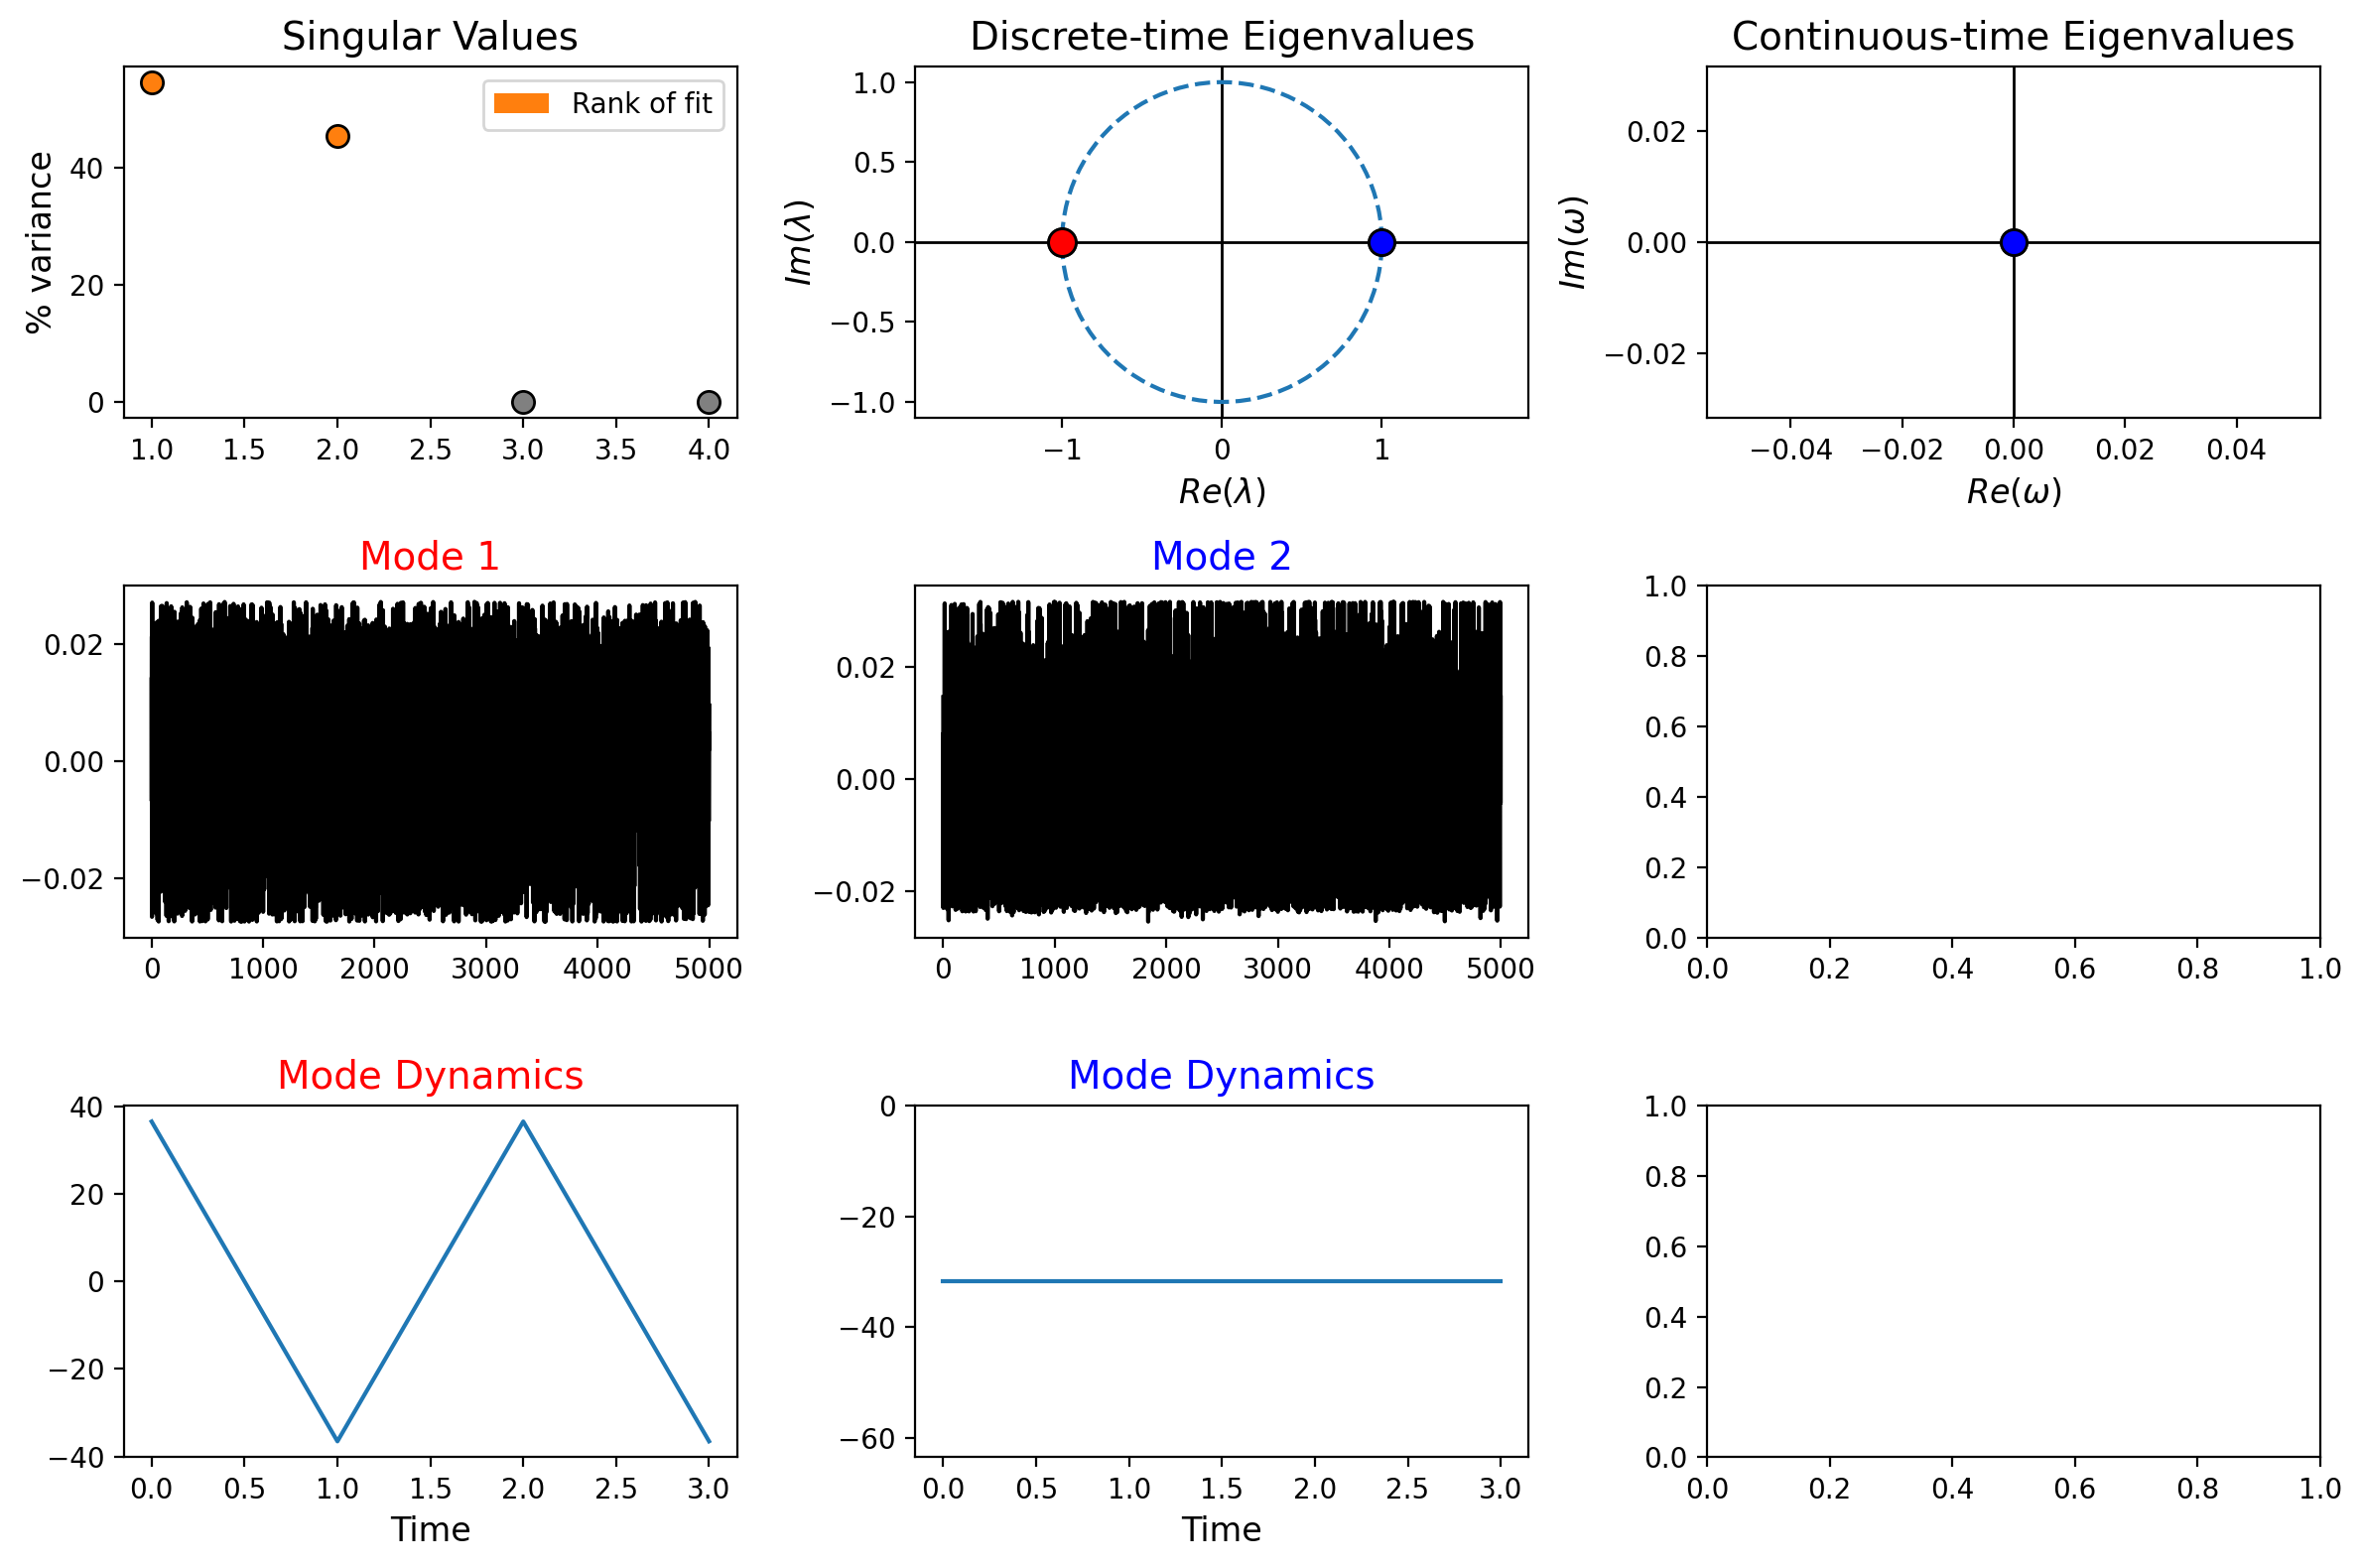

In [690]:
dmd = DMD(svd_rank=2)
dmd.fit(X=tiled)

plot_summary(dmd, index_modes=[0, 1, 2], order="F")

In [700]:
test_catted = np.concatenate(
    (
        np.expand_dims(pre_act[-sample_idx:, :].flatten(), axis=1),
        np.expand_dims(post_act[-sample_idx:, :].flatten(), axis=1),
    ),
    axis=1,
)

In [701]:
test_catted[:HEAD]

array([[-6.19e-01, 9.80e-01],
       [6.49e-01, 8.30e-01],
       [6.52e-01, -1.00e+00],
       [-1.00e+00, 9.46e-01],
       [-6.41e-01, -3.58e-01],
       [8.27e-01, -8.85e-01],
       [6.37e-01, -7.19e-04],
       [-6.40e-01, -8.02e-01],
       [6.43e-01, -9.44e-01],
       [-6.18e-01, -3.13e-01]], dtype=float32)

In [702]:
predicted = dmd.predict(X=test_catted[:, 0]).real

In [703]:
predicted[:HEAD]

array([-7.54e-01, 7.50e-01, -7.76e-01, 7.34e-01, 1.40e-01, -7.71e-01, 4.32e-02, 1.39e-01,
       -7.78e-01, 2.57e-01], dtype=float32)